In [204]:
import uproot
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
plt.style.use('belle2')
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import train_test_split
import glob
import os

import joblib

In [205]:
# Function to load and filter data from multiple files
def load_and_filter(file_paths, tree_name, cut_signal):
    branches = ['Dp_isSignal','Dp_M','Dp_CMS_cosTheta', 'Pip_cosTheta', 'Pip_p', 'Pip_mcPDG',
                'Pip_genMotherID', 'etapip_Eta_genMotherID','etapip_Eta_genMotherPDG',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [206]:
# Function to load and filter data from multiple files
def load_and_filter_ds_weight(file_paths, tree_name, cut_signal):
    branches = ['Dp_CMS_cosTheta', 'Pip_cosTheta', 'Pip_p', 'Pip_mcPDG',
                'Pip_genMotherID', 'etapip_Eta_genMotherID',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal','ds_weight']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [207]:
# Function to load and filter data from multiple files
def load_and_filter_test(file_paths, tree_name, cut_signal):
    branches = ['Dp_M','Dp_CMS_cosTheta', 'Pip_cosTheta', 'Pip_p', 'Pip_mcPDG',
                'Pip_genMotherID', 'etapip_Eta_genMotherID',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal', 'bdtg_norm', 'bdtg_weight','Dp_isSignal','bdtg','Pip_charge']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [219]:
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]

ref_tree = "etapip_pipipi_K"
tree_name = "Ks_K"
BDT_cut = 0.92

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/bdtg_Ds/*BCS.bdtg.root"
    # pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/*.root"

    file_list_ref += glob.glob(pattern)

# df_ref = load_and_filter_test(file_list_ref, "Ks","Dp_M>0")
signal_cut = 'Dp_isSignal!=1 & Dp_M>1.8 & Dp_M<1.93 & Dp_CMS_cosTheta>0'
signal_cut = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
# signal_cut = ' Dp_M>1.8 & Dp_M<1.93 & Dp_CMS_cosTheta>0'
signal_cut += ' & Dp_M>1.9 & Dp_M<2.03 & Dp_CMS_cosTheta>0'
signal_cut = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"
signal_cut += ' &  Dp_M>1.9 & Dp_M<2.03 & Dp_CMS_cosTheta>0 & Pip_charge==-1'

df_ref = load_and_filter_test(file_list_ref, "Ks_K",signal_cut)



In [217]:
df_ref['bdtg_norm'].sum()

70804.875

In [218]:
df_ref['bdtg_norm'].sum()/4

17701.21875

In [220]:
df_ref['bdtg_norm'].sum()

71288.76

In [221]:
df_ref['bdtg_norm'].sum()/4

17822.189453125

In [222]:
(70804.875- 71288.76)/(70804.875+ 71288.76)

-0.0034053953225983325

In [158]:
df_ref['bdtg_weight'].sum()/4

78074.7150975584

In [159]:
39763.31564664556 + 40274.75808117993

80038.07372782548

In [208]:
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]

ref_tree = "etapip_gg"
tree_name = "Ks"
BDT_cut = 0.83

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/bdtg/*BCS.bdtg.root"
    # pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/*.root"

    file_list_ref += glob.glob(pattern)

print(len(file_list_ref))
df_ref = load_and_filter_test(file_list_ref, "Ks_K","Dp_M>0")
signal_cut = 'Dp_isSignal==1 & Dp_M>1.8 & Dp_M<1.93'
# signal_cut = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) ) & Dp_M>1.8 & Dp_M<1.93"


df_ref = load_and_filter_test(file_list_ref, "Ks",signal_cut)



33


In [209]:
nan_columns = df_ref.isnull().any()
print(nan_columns)

Dp_M                      False
Dp_CMS_cosTheta           False
Pip_cosTheta              False
Pip_p                     False
Pip_mcPDG                 False
Pip_genMotherID           False
etapip_Eta_genMotherID    False
Pip_genMotherPDG          False
etapip_Eta_isSignal       False
bdtg_norm                 False
bdtg_weight               False
Dp_isSignal               False
bdtg                      False
Pip_charge                False
dtype: bool


In [210]:
len(df_ref)

6246

In [211]:
df_ref['bdtg_norm'].sum()

6246.0

In [202]:
df_ref['bdtg_norm'].describe()

count    380790.000000
mean          1.004256
std           0.059968
min           0.121609
25%           0.977327
50%           1.002543
75%           1.040631
max           2.840352
Name: bdtg_norm, dtype: float64

In [203]:
df_ref['bdtg_weight'].sum()/4

38811.175012437685

In [194]:
df_ref['bdtg_weight'].describe()

count    380790.000000
mean          0.407691
std           0.219682
min           0.039559
25%           0.317904
50%           0.333159
75%           0.343318
max           1.000000
Name: bdtg_weight, dtype: float64

In [195]:
df_ref['bdtg'].describe()

count    380790.000000
mean          0.276634
std           0.083293
min           0.038053
25%           0.241220
50%           0.249902
75%           0.255575
max           0.500000
Name: bdtg, dtype: float64

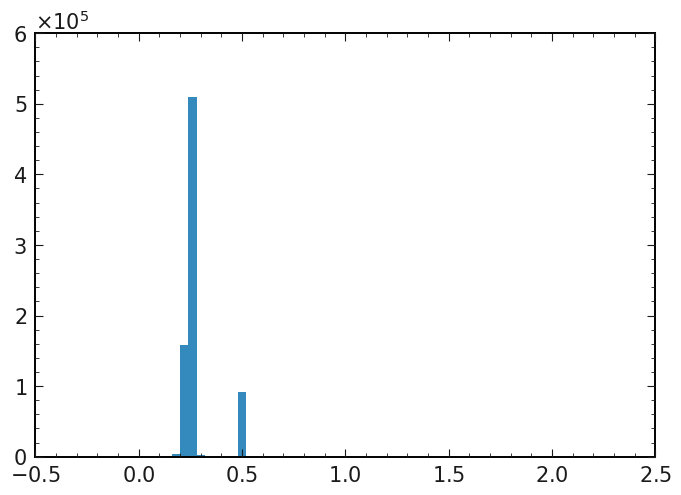

In [175]:
plt.hist(df_ref['bdtg'], bins = np.linspace(0,2,51));

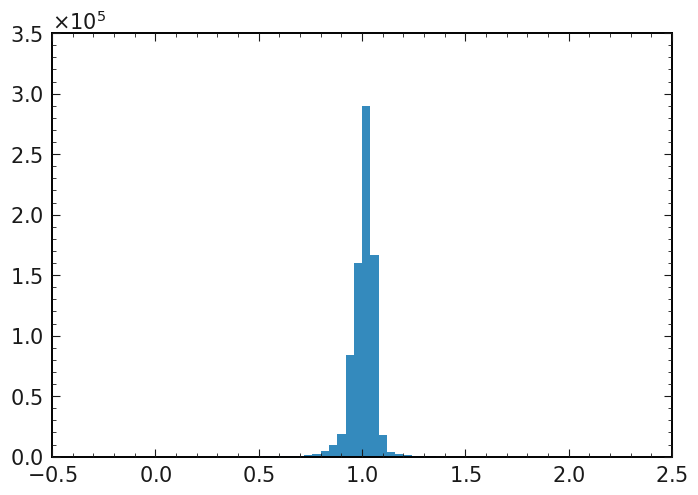

In [176]:
plt.hist(df_ref['bdtg_norm'], bins = np.linspace(0,2,51));

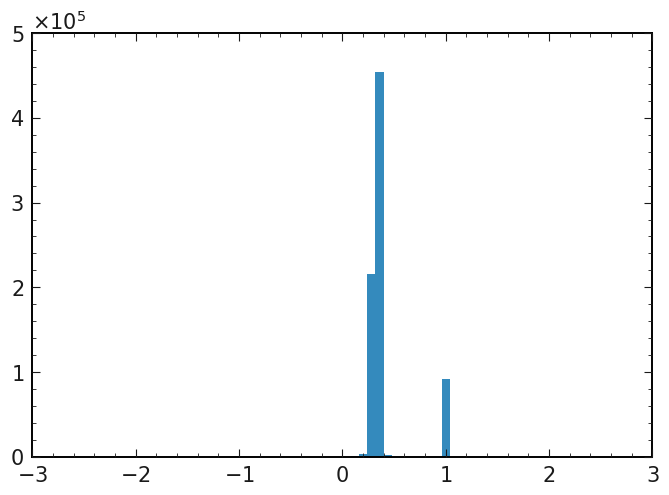

In [177]:
plt.hist(df_ref['bdtg_weight'], bins = np.linspace(-2,2,51));

In [134]:
df_ref.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_mcPDG,Pip_genMotherID,etapip_Eta_genMotherID,Pip_genMotherPDG,etapip_Eta_isSignal,bdtg_norm,bdtg_weight,Dp_isSignal,bdtg
count,91804.000000,91804.000000,91804.000000,91804.000000,89522.000000,91804.000000,91804.000000,9.180400e+04,87705.000000,91804.0,91804.0,85322.0,91804.0
mean,1.857388,0.479611,0.669731,1.693874,-3.817665,6.920559,9.913544,1.797666e+03,0.913232,1.0,1.0,0.0,0.5
std,0.035885,0.269515,0.305402,0.950040,592.643873,6.103810,7.007316,1.260463e+05,0.281497,0.0,0.0,0.0,0.0
min,1.800001,0.000016,-0.865807,0.400030,-3312.000000,0.000000,0.000000,-2.042300e+04,0.000000,1.0,1.0,0.0,0.5
25%,1.826156,0.252572,0.537875,0.860865,-211.000000,2.000000,5.000000,-3.130000e+02,1.000000,1.0,1.0,0.0,0.5
50%,1.856056,0.483428,0.768063,1.598337,-11.000000,6.000000,8.000000,2.300000e+01,1.000000,1.0,1.0,0.0,0.5
75%,1.884872,0.702267,0.905226,2.335032,211.000000,9.000000,13.000000,3.130000e+02,1.000000,1.0,1.0,0.0,0.5
max,1.929999,0.999939,0.974074,5.757412,3312.000000,79.000000,69.000000,9.010221e+06,1.000000,1.0,1.0,0.0,0.5


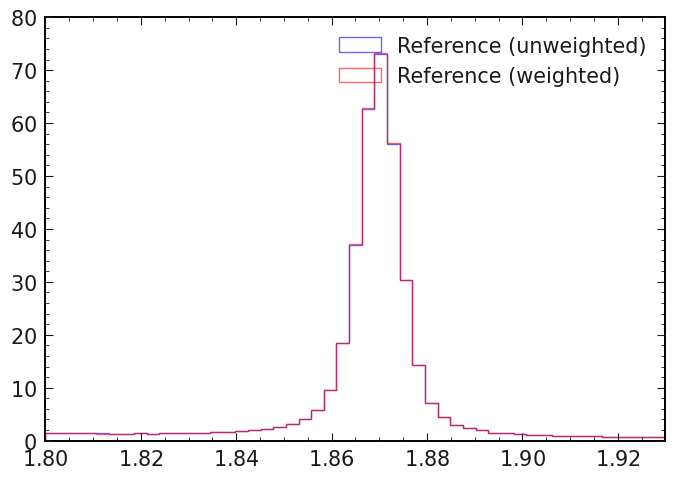

In [178]:
bins = np.linspace(1.8, 1.93, 50)
plt.hist(df_ref['Dp_M'], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Reference (unweighted)', color='blue')
plt.hist(df_ref['Dp_M'], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['bdtg_norm'], label='Reference (weighted)', color='red')

# plt.hist(df_signal['Dp_M'], bins=bins, density=True, alpha=0.6,
                   # histtype='step', label='Signal', color='green')
plt.xlim(bins[0], bins[-1])
plt.legend()

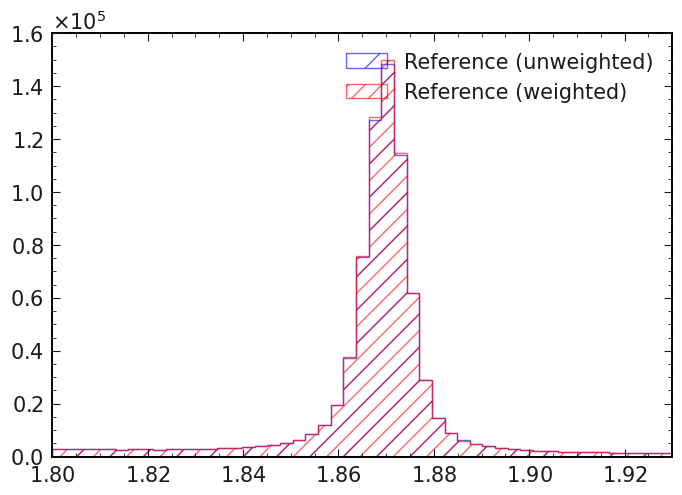

In [179]:
bins = np.linspace(1.8, 1.93, 50)
plt.hist(df_ref['Dp_M'], bins=bins, density=False, alpha=0.6,
                   histtype='step', label='Reference (unweighted)', color='blue',hatch='/')
plt.hist(df_ref['Dp_M'], bins=bins, density=False, alpha=0.6,
                   histtype='step', weights=df_ref['bdtg_norm'], label='Reference (weighted)', color='red',hatch='//')

plt.xlim(bins[0], bins[-1])
plt.legend()

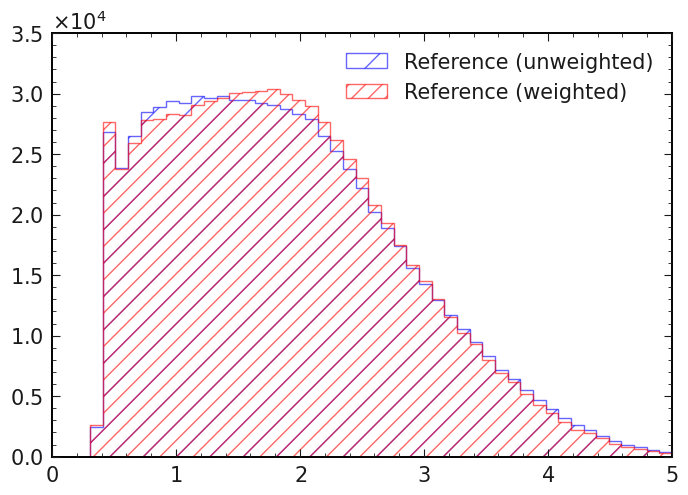

In [180]:
bins = np.linspace(0, 5, 50)
plt.hist(df_ref['Pip_p'], bins=bins, density=False, alpha=0.6,
                   histtype='step', label='Reference (unweighted)', color='blue',hatch='/')
plt.hist(df_ref['Pip_p'], bins=bins, density=False, alpha=0.6,
                   histtype='step', weights=df_ref['bdtg_norm'], label='Reference (weighted)', color='red',hatch='//')

plt.xlim(bins[0], bins[-1])
plt.legend()

In [456]:
signal_cut = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"

In [457]:
signal_mask = df_ref.eval(signal_cut)

In [411]:
signal_mask.unique()

array([ True])

In [465]:
len(df_ref)

34974

In [413]:
df_ref_test['ds_weight'].sum()

467872.84

In [414]:
df_ref_test['bdtg_weight'].sum()

458371.5

In [459]:
df_ref['bdtg_norm'].sum()

34974.0

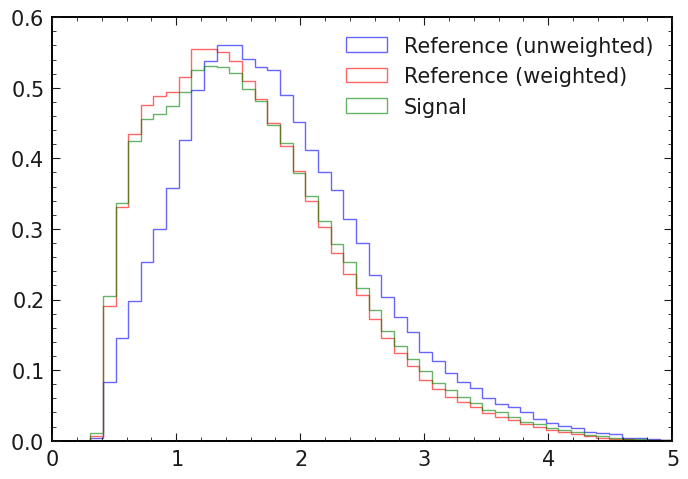

In [416]:
# bins = np.linspace(0, 5, 50)
# plt.hist(df_ref['Pip_p'], bins=bins, density=True, alpha=0.6,
#                    histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', color='blue')
# plt.hist(df_ref['Pip_p'], bins=bins, density=True, alpha=0.6,
#                    histtype='step', weights=df_ref['bdtg_norm'], label='Reference (weighted)', color='red')

# plt.hist(df_signal['Pip_p'], bins=bins, density=True, alpha=0.6,
#                    histtype='step', label='Signal', color='green')
# plt.xlim(bins[0], bins[-1])
# plt.legend()

In [113]:
df_ref.query(signal_cut)['ds_weight'].sum()

251353.77

In [114]:
df_ref.query(signal_cut)['bdtg_norm'].sum()

247139.14

In [429]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dp_K
cut_signal_Dsp = signal_cut_Dsp_K


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_pipipi/250216_loose_v7/etapip_pipipi_K/min_unc_search/new_Ds_v2/0.92/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_pipipi_cc/250216_loose_v7/etapip_pipipi_K/min_unc_search/new_Ds_v2/0.92/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_pipipi_K", cut_signal_Dp)
df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가
N_signal = len(df_signal)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_pipipi_K"
tree_name = "Ks_K"
BDT_cut = 0.92

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
combined_df = pd.concat([df_signal, df_ref], ignore_index=True)


X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# # === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}.pkl'")
# model_file = f"xgb_model_{ref_tree}.pkl"
# model = joblib.load(model_file)

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_pipipi_K.pkl'


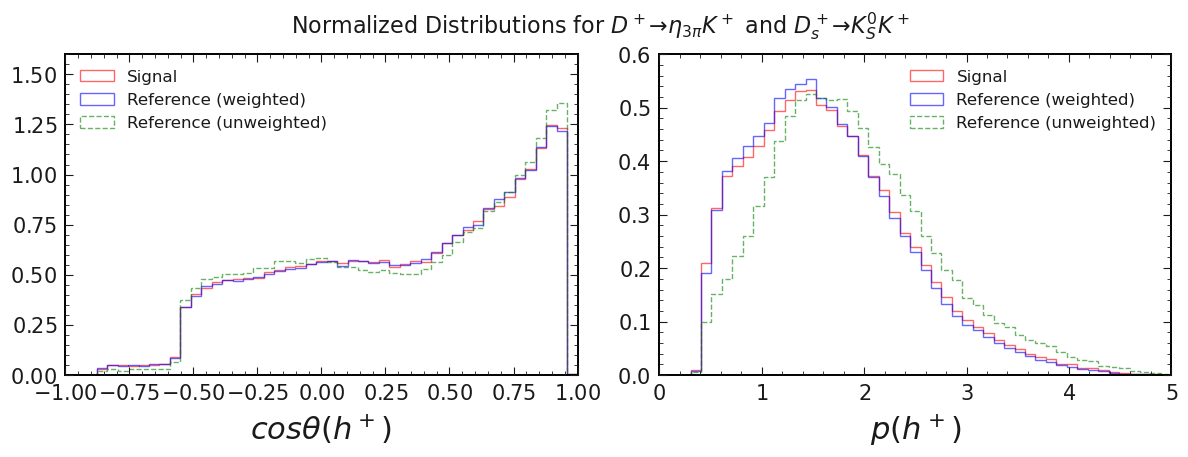

In [430]:

mode = r"$D^+ \to \eta_{3\pi} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    # axes[idx].axvline(x=-0.55, color='k', linestyle='--', linewidth=1)

    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode}', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"etapip_pipipi_K_2_vars_reweighting.pdf")
plt.show()

In [55]:
239106/266730.25



0.8964337565761664

In [54]:
len(df_ref)

239106

In [51]:
df_ref['ds_weight'].sum()

266730.25

In [52]:
df_ref['weight'].sum()

266730.28

In [53]:
np.isclose(df_ref['weight'].sum(), df_ref['ds_weight'].sum())  # → True ✅


True

In [427]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dp_K
cut_signal_Dsp = signal_cut_Dsp_K

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg/250216_loose_v7/etapip_gg_K/min_unc_search/new_Ds_v2/0.91/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg_cc/250216_loose_v7/etapip_gg_K/min_unc_search/new_Ds_v2/0.91/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_gg_K", cut_signal_Dp)
df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"
BDT_cut = 0.91

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)
# === Train XGBoost ===
model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}.pkl'")

# model_file = f"xgb_model_{ref_tree}.pkl"
# model = joblib.load(model_file)

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_gg_K.pkl'


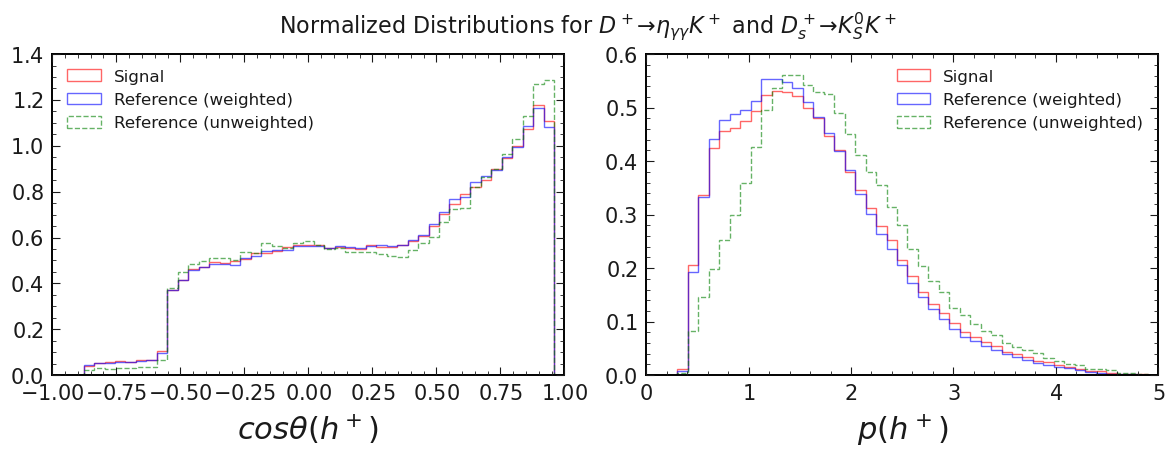

In [428]:

mode = r"$D^+ \to \eta_{\gamma\gamma} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# for idx, var in enumerate(variables):
#     bins = bins_dict[var]
#     axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal',color='red')
#     axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_ref['weight'], label='Reference (weighted)',color='blue')
#     axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Reference (unweighted)', linestyle='--',color='green')
#     # axes[idx].set_title(f'Normalized Distribution')
#     axes[idx].set_title(f'{mode}')
#     axes[idx].set_xlim(bins[0], bins[-1])
#     axes[idx].set_xlabel(f'{var_info[var]}')
#     axes[idx].legend(loc=legend_loc[var])

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode}', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"etapip_gg_K_2_vars_reweighting.pdf")
plt.show()

In [431]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_K
cut_signal_Dsp = signal_cut_Dsp_K


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_pipipi/250216_loose_v7/etapip_pipipi_K/min_unc_search/new_Ds_v2/0.92/weighted/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_pipipi_cc/250216_loose_v7/etapip_pipipi_K/min_unc_search/new_Ds_v2/0.92/weighted/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_pipipi_K", cut_signal_Dp)
# df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_pipipi_K"
tree_name = "Ks_K"
BDT_cut = 0.92

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# # === Train-test split ===
# X_train, X_test, y_train, y_test = train_test_split(
#     combined_df[variables], combined_df['label'], combined_df['ds_weight'], test_size=0.3, random_state=42
# )

# # === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
# model.fit(X_train, y_train)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_Ds_{ref_tree}.pkl")
print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_Ds_etapip_pipipi_K.pkl'


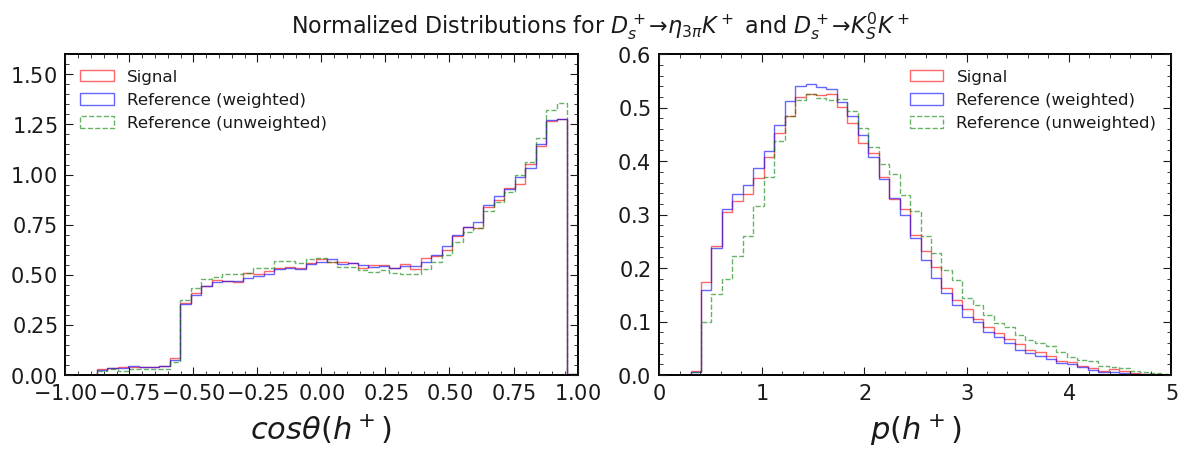

In [433]:

mode = r"$D^+_s \to \eta_{3\pi} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode}', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"Ds_etapip_pipipi_K_2_vars_reweighting.pdf")
plt.show()

In [436]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_K
cut_signal_Dsp = signal_cut_Dsp_K


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg/250216_loose_v7/etapip_gg_K/min_unc_search/new_Ds_v2/0.91/weighted/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg_cc/250216_loose_v7/etapip_gg_K/min_unc_search/new_Ds_v2/0.91/weighted/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_gg_K", cut_signal_Dp)
# df_signal['ds_weight'] = 1.0  # ✅ signal weight 추가

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"
BDT_cut = 0.91

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/weighted/weighted*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter_ds_weight(file_list_ref, "Ks_K",cut_signal_Dsp)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
combined_df = pd.concat([df_signal, df_ref], ignore_index=True)


X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
# joblib.dump(model, f"xgb_model_Ds_{ref_tree}.pkl")
# print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


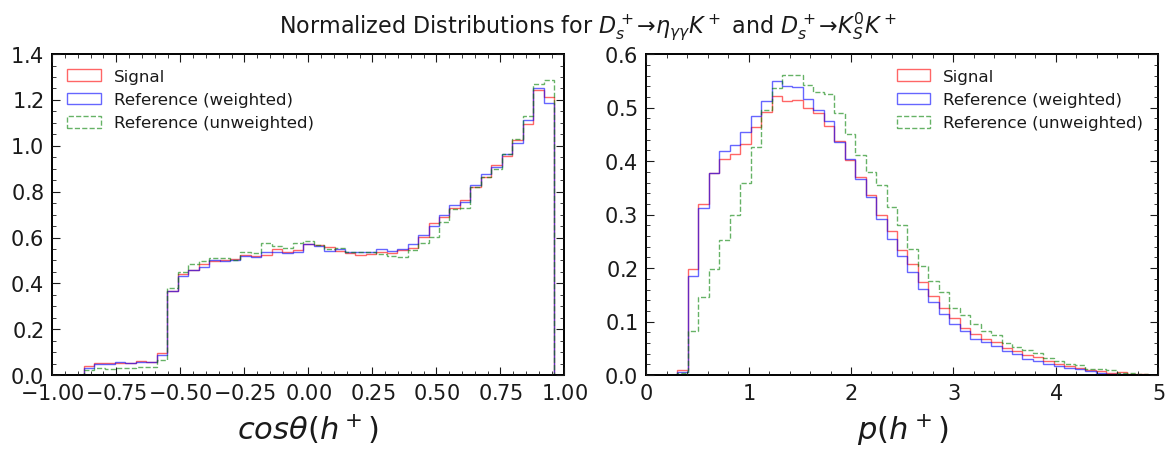

In [435]:

mode = r"$D^+_s \to \eta_{\gamma\gamma} K^+$"
ref_mode = r"$D^+_s \to K_S^0 K^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode}', fontsize=16, y=0.92)
plt.tight_layout()

# plt.savefig(f"Ds_etapip_gg_K_2_vars_reweighting.pdf")
plt.show()

In [438]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for the signal dataset
proba_signal = model.predict_proba(df_signal[variables])[:, 1]

# Combine true labels and predicted probabilities
y_true = pd.concat([df_signal['label'], df_ref['label']])
y_scores = pd.concat([proba_signal, proba_ref])

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

TypeError: cannot concatenate object of type '<class 'numpy.ndarray'>'; only Series and DataFrame objs are valid

In [ ]:
-1 + (2)/100*20

In [ ]:
plt.hist(df_signal['Pip_cosTheta'], bins = np.linspace(-1,1,101))

In [ ]:
plt.hist(df_ref['weight'],bins=np.linspace(0,1.2,51))

In [ ]:
proba_ref

In [ ]:
plt.hist(proba_ref,bins=np.linspace(0,0.2,51))